# 1. Importing Dependencies

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split, cross_val_score, RandomizedSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import pickle
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
!pip install fuzzywuzzy python-Levenshtein -q
from fuzzywuzzy import fuzz
import warnings
warnings.filterwarnings('ignore')
print('✅ Libraries loaded successfully!')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 153.3/153.3 kB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 65.4 MB/s eta 0:00:00
✅ Libraries loaded successfully!


# 2. Data Loading & Understanding

In [ ]:
data = pd.read_csv("/content/train.csv")
print(f'Shape: {data.shape}')
data.head()

Shape: (800, 22)


,ID,A1_Score,A2_Score,A3_Score,A4_Score,A5_Score,A6_Score,A7_Score,A8_Score,A9_Score,...,gender,ethnicity,jaundice,austim,contry_of_res,used_app_before,result,age_desc,relation,Class/ASD
0,1,1,0,1,0,1,0,1,0,1,...,f,?,no,no,Austria,no,6.351166,18 and more,Self,0
1,2,0,0,0,0,0,0,0,0,0,...,m,?,no,no,India,no,2.255185,18 and more,Self,0
2,3,1,1,1,1,1,1,1,1,1,...,m,White-European,no,yes,United States,no,14.851484,18 and more,Self,1
3,4,0,0,0,0,0,0,0,0,0,...,f,?,no,no,United States,no,2.276617,18 and more,Self,0
4,5,0,0,0,0,0,0,0,0,0,...,m,?,no,no,South Africa,no,-4.777286,18 and more,Self,0


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 22 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ID               800 non-null    int64  
 1   A1_Score         800 non-null    int64  
 2   A2_Score         800 non-null    int64  
 3   A3_Score         800 non-null    int64  
 4   A4_Score         800 non-null    int64  
 5   A5_Score         800 non-null    int64  
 6   A6_Score         800 non-null    int64  
 7   A7_Score         800 non-null    int64  
 8   A8_Score         800 non-null    int64  
 9   A9_Score         800 non-null    int64  
 10  A10_Score        800 non-null    int64  
 11  age              800 non-null    float64
 12  gender           800 non-null    object 
 13  ethnicity        800 non-null    object 
 14  jaundice         800 non-null    object 
 15  austim           800 non-null    object 
 16  contry_of_res    800 non-null    object 
 17  used_app_before 

In [ ]:
data.rename(columns={'austim': 'autsim'}, inplace=True)

In [ ]:
# Convert age to integer
data['age'] = data['age'].astype(int)

# Check unique values for non-numerical columns
numerical_features = ["ID", "age", "result"]
for col in data.columns:
    if col not in numerical_features:
        print(f"{col} : {data[col].unique()}")
        print("-" * 50)

A1_Score : [1 0]
--------------------------------------------------
A2_Score : [0 1]
--------------------------------------------------
A3_Score : [1 0]
--------------------------------------------------
A4_Score : [0 1]
--------------------------------------------------
A5_Score : [1 0]
--------------------------------------------------
A6_Score : [0 1]
--------------------------------------------------
A7_Score : [1 0]
--------------------------------------------------
A8_Score : [0 1]
--------------------------------------------------
A9_Score : [1 0]
--------------------------------------------------
A10_Score : [1 0]
--------------------------------------------------
gender : ['f' 'm']
--------------------------------------------------
ethnicity : ['?' 'White-European' 'Middle Eastern ' 'Pasifika' 'Black' 'Others'
 'Hispanic' 'Asian' 'Turkish' 'South Asian' 'Latino' 'others']
--------------------------------------------------
jaundice : ['no' 'yes']
-------------------------------

In [ ]:
# Drop ID and age_desc (age_desc has only 1 unique value)
data = data.drop(columns=["ID", "age_desc"])
print(f'Shape after dropping: {data.shape}')

Shape after dropping: (800, 20)


# 3. Exploratory Data Analysis (EDA)

In [ ]:
# Fix fuzzy country names
unique_vals = data['contry_of_res'].unique()
for i in range(len(unique_vals)):
    for j in range(i + 1, len(unique_vals)):
        similarity = fuzz.ratio(unique_vals[i], unique_vals[j])
        if similarity > 80:
            print(unique_vals[i], '↔', unique_vals[j], similarity)

mapping = {'Viet Nam': 'Vietnam', 'AmericanSamoa': 'United States'}
data['contry_of_res'] = data['contry_of_res'].replace(mapping)
print('\n✅ Country names fixed!')

Austria ↔ Australia 88
Ireland ↔ Iceland 86

✅ Country names fixed!


Target Distribution:
Class/ASD
0    639
1    161
Name: count, dtype: int64


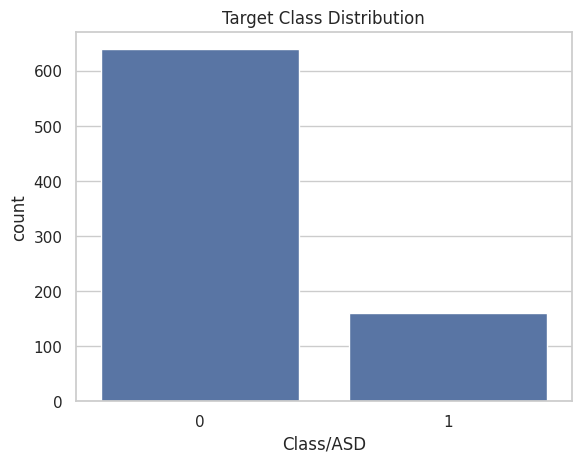

In [ ]:
# Class distribution
print('Target Distribution:')
print(data['Class/ASD'].value_counts())

sns.set_theme(style='whitegrid')
sns.countplot(x=data['Class/ASD'])
plt.title('Target Class Distribution')
plt.show()

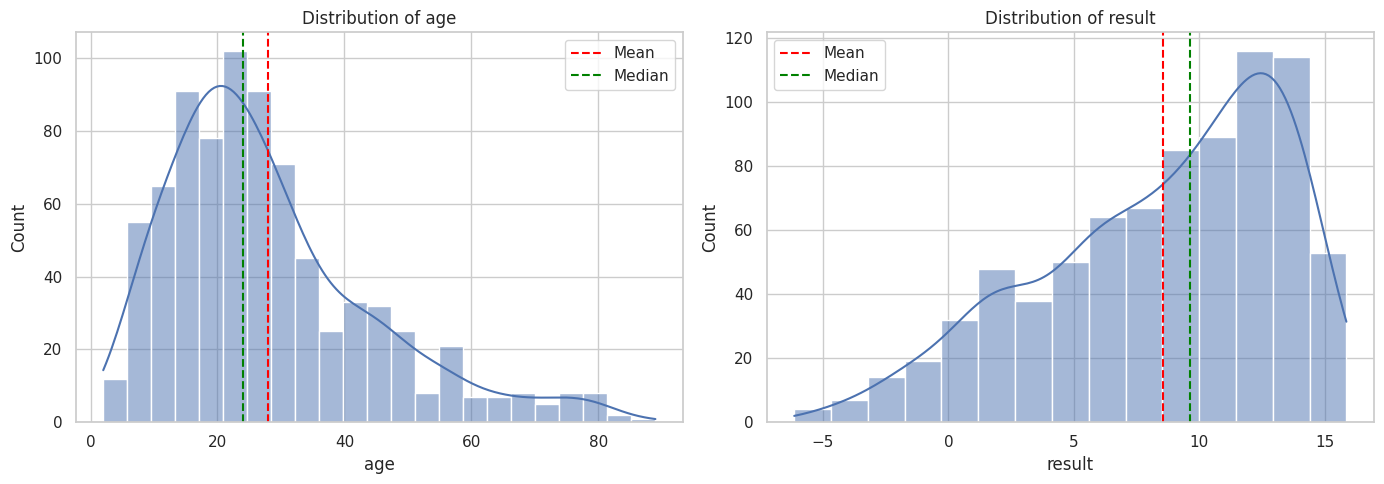

In [ ]:
# Distribution of numerical features
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, col in zip(axes, ['age','result']):
    sns.histplot(data[col], kde=True, ax=ax)
    ax.axvline(data[col].mean(), color='red', linestyle='--', label='Mean')
    ax.axvline(data[col].median(), color='green', linestyle='--', label='Median')
    ax.set_title(f'Distribution of {col}')
    ax.legend()

plt.tight_layout()
plt.show()

Box Plots for identifying outliers in the numerical columns

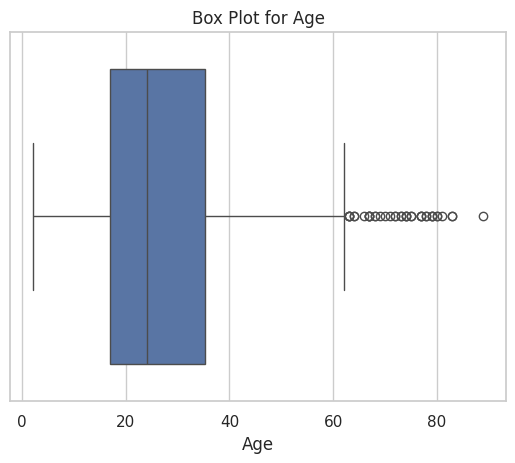

In [ ]:
# box plot
sns.boxplot(x=data['age'])
plt.title('Box Plot for Age')
plt.xlabel('Age')
plt.show()

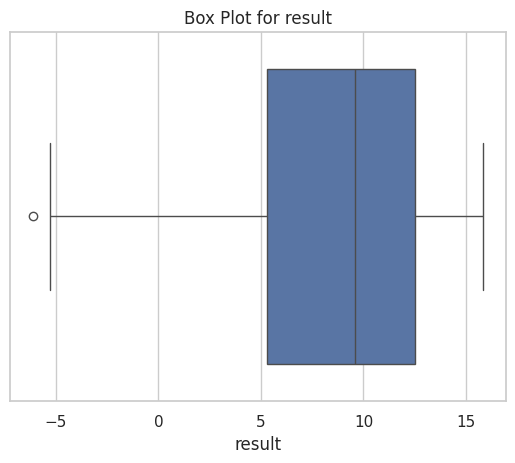

In [ ]:
# box plot
sns.boxplot(x=data['result'])
plt.title('Box Plot for result')
plt.xlabel('result')
plt.show()

Univariate analysis of Categorical columns

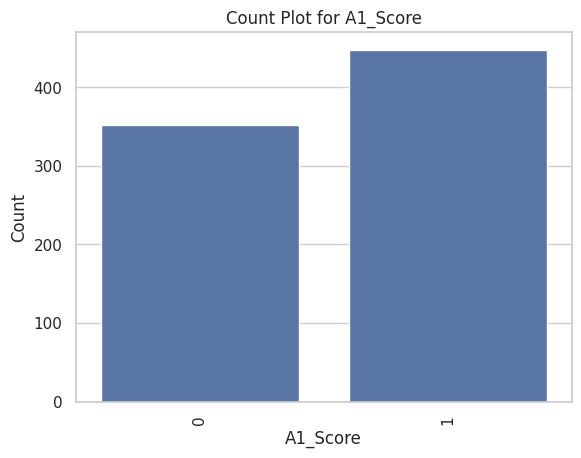

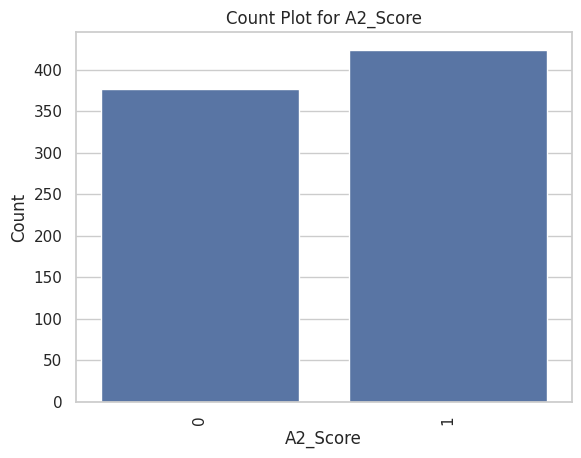

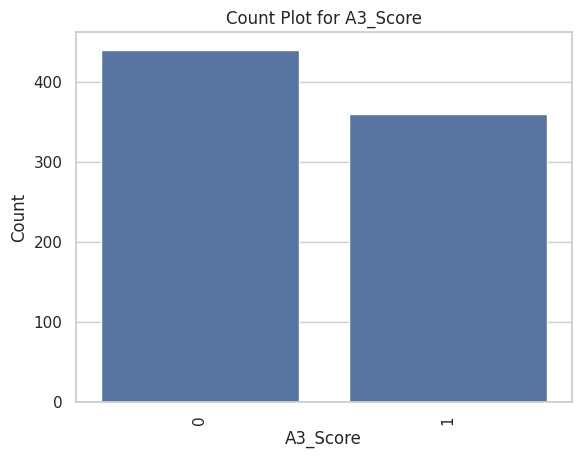

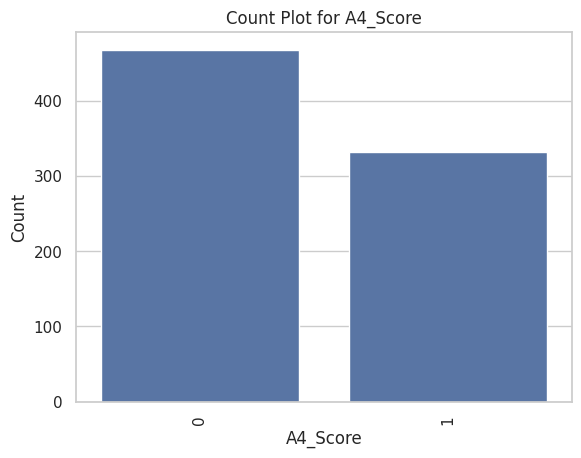

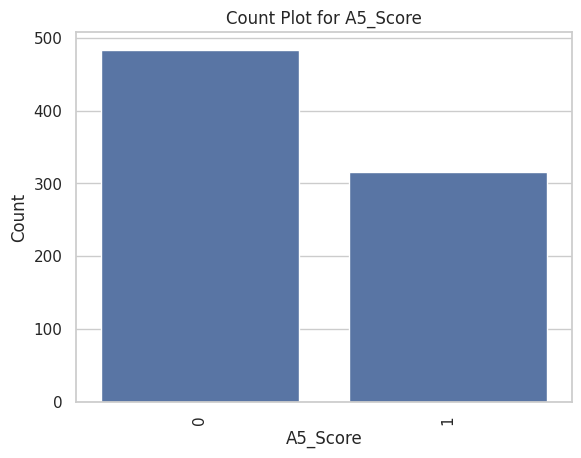

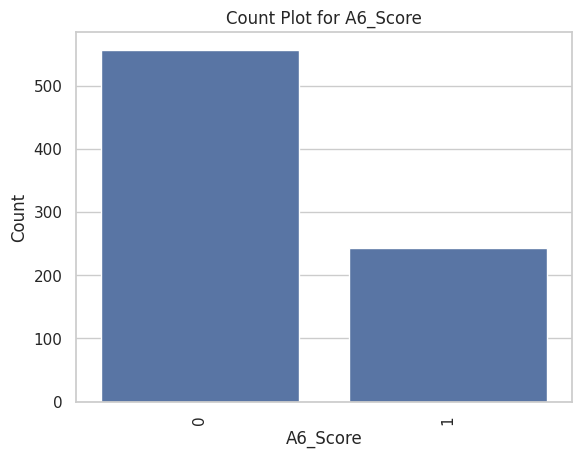

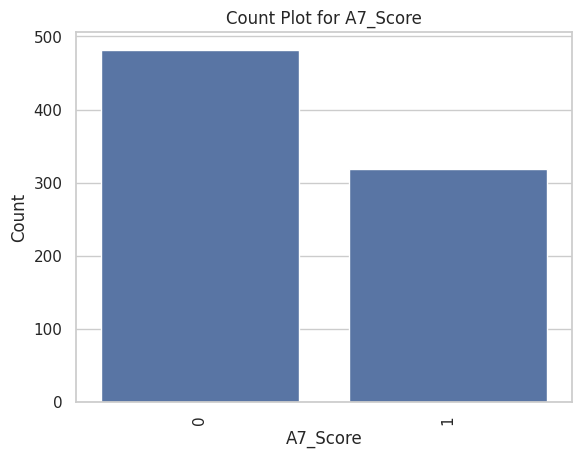

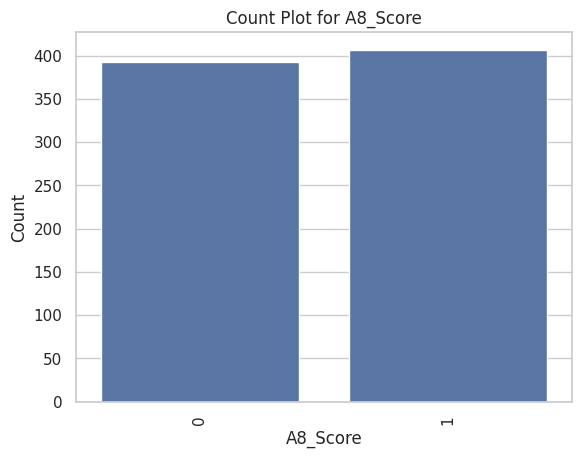

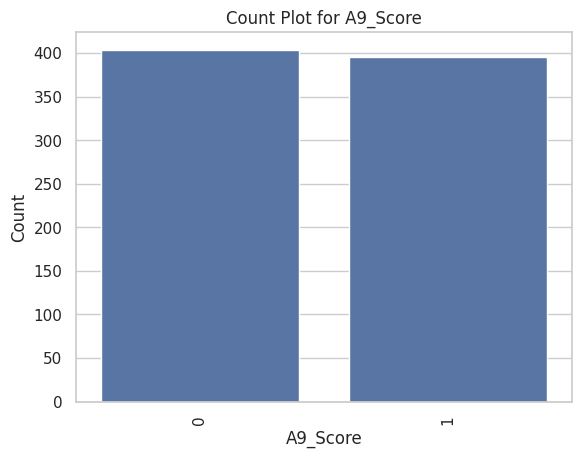

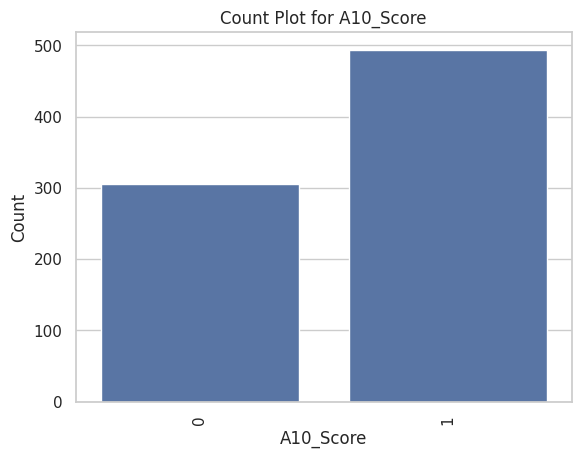

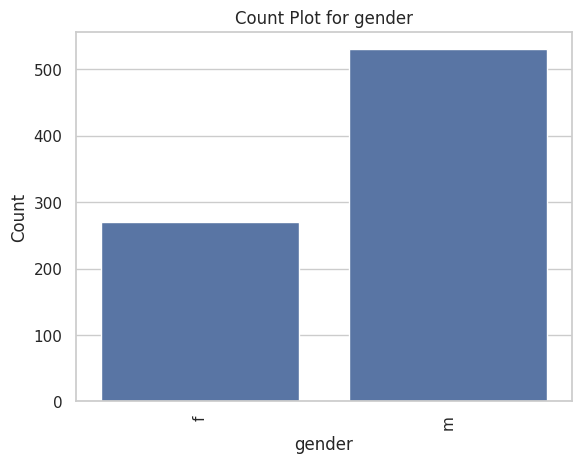

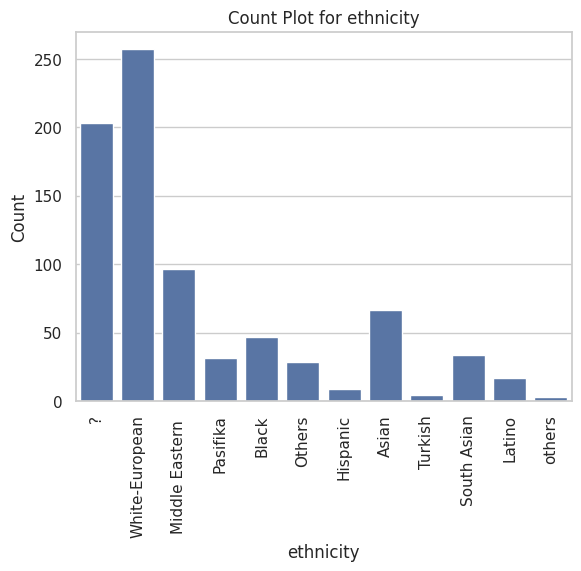

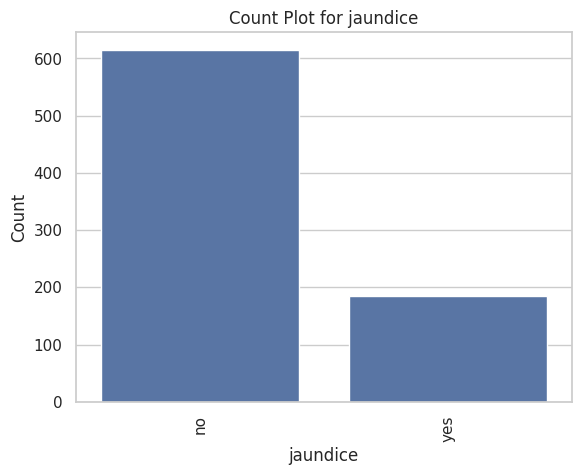

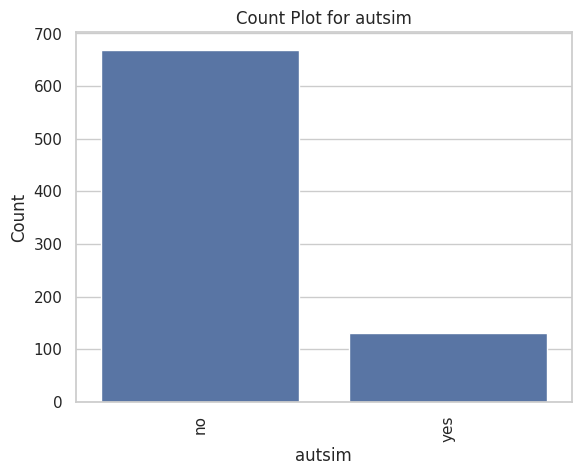

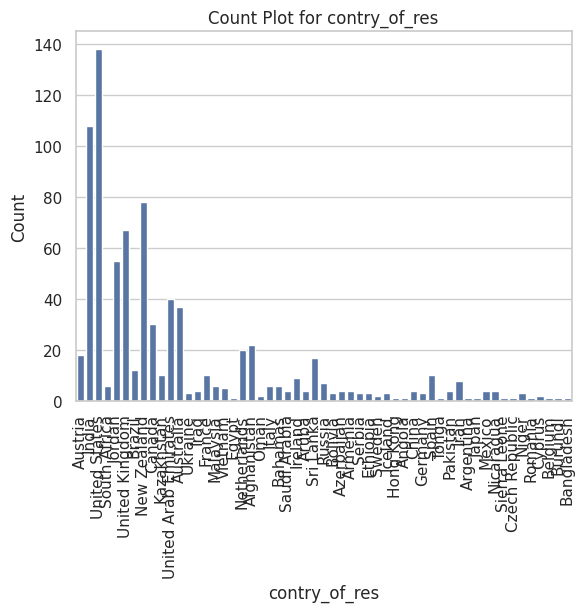

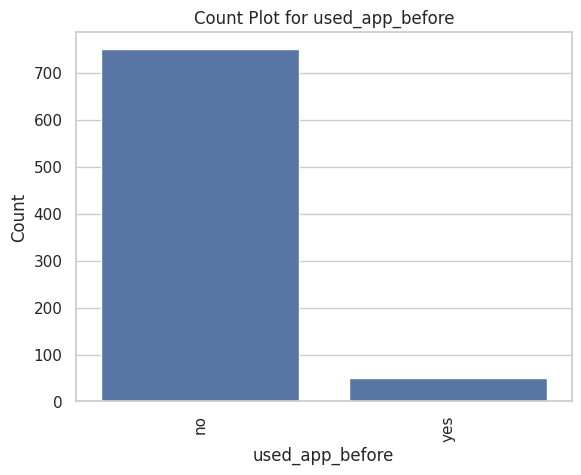

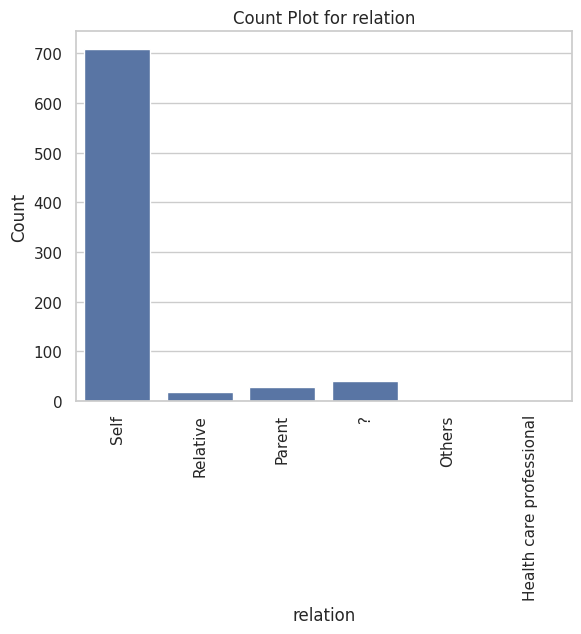

In [ ]:
categorical_columns = ['A1_Score', 'A2_Score', 'A3_Score', 'A4_Score', 'A5_Score', 'A6_Score',
       'A7_Score', 'A8_Score', 'A9_Score', 'A10_Score',  'gender',
       'ethnicity', 'jaundice', 'autsim', 'contry_of_res', 'used_app_before',
       'relation']

for col in categorical_columns:
  sns.countplot(x=data[col])
  plt.title(f"Count Plot for {col}")
  plt.xlabel(col)
  plt.ylabel("Count")
  plt.xticks(rotation=90)
  plt.show()

# 4. Data Preprocessing

In [ ]:
# Fix missing values in ethnicity and relation
data['ethnicity'] = data['ethnicity'].replace({'?': 'Others', 'others': 'Others'})
data['relation'] = data['relation'].replace({
    '?': 'Others',
    'Relative': 'Others',
    'Parent': 'Others',
    'Health care professional': 'Others'
})
print('✅ Missing values handled!')

✅ Missing values handled!


In [ ]:
# Handle outliers using IQR median replacement
def replace_outliers_with_median(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    median = df[column].median()
    df[column] = df[column].apply(lambda x: median if x < lower_bound or x > upper_bound else x)
    return df

data = replace_outliers_with_median(data, 'age')
data = replace_outliers_with_median(data, 'result')
print('✅ Outliers handled!')

✅ Outliers handled!


In [ ]:
# Label Encoding
object_columns = data.select_dtypes(include=['object']).columns
encoders = {}

for column in object_columns:
    label_encoder = LabelEncoder()
    data[column] = label_encoder.fit_transform(data[column])
    encoders[column] = label_encoder

with open('encoders.pkl', 'wb') as f:
    pickle.dump(encoders, f)

print('✅ Label Encoding done!')
data.head()

✅ Label Encoding done!


,A1_Score,A2_Score,A3_Score,A4_Score,A5_Score,A6_Score,A7_Score,A8_Score,A9_Score,A10_Score,age,gender,ethnicity,jaundice,autsim,contry_of_res,used_app_before,result,relation,Class/ASD
0,1,0,1,0,1,0,1,0,1,1,38.0,0,5,0,0,6,0,6.351166,1,0
1,0,0,0,0,0,0,0,0,0,0,47.0,1,5,0,0,24,0,2.255185,1,0
2,1,1,1,1,1,1,1,1,1,1,7.0,1,9,0,1,53,0,14.851484,1,1
3,0,0,0,0,0,0,0,0,0,0,23.0,0,5,0,0,53,0,2.276617,1,0
4,0,0,0,0,0,0,0,0,0,0,43.0,1,5,0,0,45,0,-4.777286,1,0


In [ ]:
encoders.keys()

dict_keys(['gender', 'ethnicity', 'jaundice', 'autsim', 'contry_of_res', 'used_app_before', 'relation'])

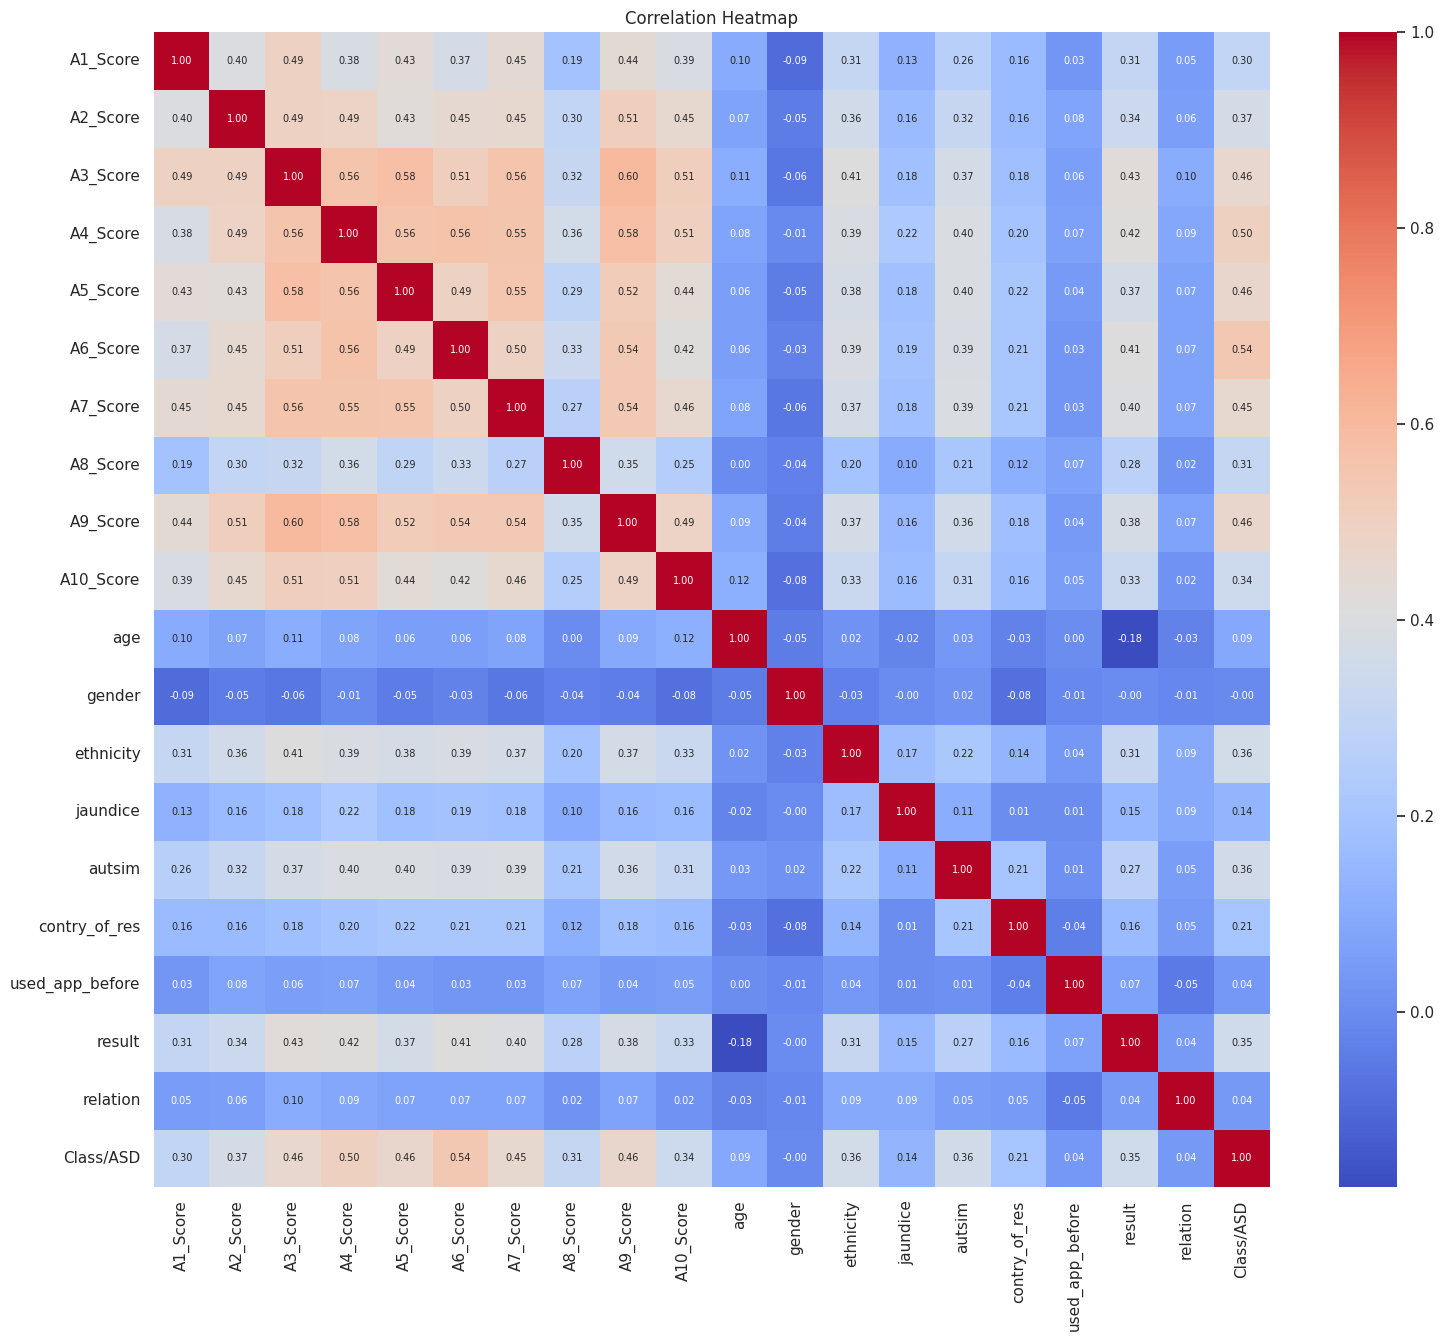

In [ ]:
# Correlation Heatmap
plt.figure(figsize=(18, 15))
sns.heatmap(data.corr(), annot=True, cmap='coolwarm', fmt='.2f', annot_kws={'size': 7})
plt.title('Correlation Heatmap')
plt.show()

# Insights From EDA :


*   There are few outliers in the numerical columns (age,results)

*  There is a class imbalance in the target column
*   There is a class imbalance in the categorical features


*   we do not have any highly correlated column performed label encoding and saved the encoders






# 5. Train-Test Split & Scaling

In [ ]:
X = data.drop(columns=['Class/ASD'])
y = data['Class/ASD']

x_train, x_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print(f'Train size: {x_train.shape}, Test size: {x_test.shape}')
print(f'Train class distribution:\n{y_train.value_counts()}')

Train size: (640, 19), Test size: (160, 19)
Train class distribution:
Class/ASD
0    511
1    129
Name: count, dtype: int64


In [ ]:
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled  = scaler.transform(x_test)

# Save the scaler
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print('✅ Scaling done correctly (no data leakage)!')

✅ Scaling done correctly (no data leakage)!


In [ ]:
#SMOTE
smote = SMOTE(random_state=42)
x_train_smote, y_train_smote = smote.fit_resample(x_train_scaled, y_train)

print(f'After SMOTE shape: {x_train_smote.shape}')
print(f'Class distribution after SMOTE:\n{pd.Series(y_train_smote).value_counts()}')

After SMOTE shape: (1022, 19)
Class distribution after SMOTE:
Class/ASD
0    511
1    511
Name: count, dtype: int64


# 6. Model Training (Cross-Validation)

In [ ]:
models = {
    'DecisionTreeClassifier': DecisionTreeClassifier(random_state=42),
    'RandomForestClassifier': RandomForestClassifier(random_state=42, n_jobs=-1),
    'XGBClassifier': XGBClassifier(random_state=42, eval_metric='logloss'),
    'GradientBoostingClassifier': GradientBoostingClassifier(random_state=42)
}

cv_scores = {}
for model_name, model in models.items():
    scores = cross_val_score(model, x_train_smote, y_train_smote, cv=5, scoring='accuracy', n_jobs=-1)
    cv_scores[model_name] = scores
    print(f'{model_name}: {np.mean(scores):.4f}')
    print('-' * 60)

DecisionTreeClassifier: 0.8739
------------------------------------------------------------
RandomForestClassifier: 0.9199
------------------------------------------------------------
XGBClassifier: 0.9013
------------------------------------------------------------
GradientBoostingClassifier: 0.8974
------------------------------------------------------------


# 7. Hyperparameter Tuning

In [ ]:
param_grid_dt = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [None, 10, 20, 30, 50],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

param_grid_rf = {
    'n_estimators': [100, 200, 500],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

# Bug Fix: colsample_by → colsample_bytree
param_grid_xgb = {
    'n_estimators': [100, 200, 500],
    'max_depth': [3, 5, 7, 10],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'min_child_weight': [1, 3, 5],
    'gamma': [0, 0.1, 0.3]
}
param_grid_gb = {
    'n_estimators'      : [100, 200, 300, 500],
    'learning_rate'     : [0.01, 0.05, 0.1, 0.2],
    'max_depth'         : [3, 4, 5, 6, 8],
    'min_samples_split' : [2, 5, 10, 20],
    'min_samples_leaf'  : [1, 2, 4, 8],
    'subsample'         : [0.6, 0.7, 0.8, 1.0],
    'max_features'      : ['sqrt', 'log2', None],
    'loss'              : ['log_loss', 'exponential'],
}

In [ ]:
decision_tree = DecisionTreeClassifier(random_state=42)
random_forest = RandomForestClassifier(random_state=42, n_jobs=-1)
xgboost = XGBClassifier(random_state=42, eval_metric='logloss', n_jobs=-1)
gb_base = GradientBoostingClassifier(random_state=42)

random_search_dt = RandomizedSearchCV(
    estimator=decision_tree, param_distributions=param_grid_dt,
    n_iter=20, cv=5, scoring='recall', random_state=42, n_jobs=-1
)
random_search_rf = RandomizedSearchCV(
    estimator=random_forest, param_distributions=param_grid_rf,
    n_iter=20, cv=5, scoring='recall', random_state=42, n_jobs=-1
)
random_search_xgb = RandomizedSearchCV(
    estimator=xgboost, param_distributions=param_grid_xgb,
    n_iter=20, cv=5, scoring='recall', random_state=42, n_jobs=-1
)
random_search_gb = RandomizedSearchCV(
    estimator           = gb_base,
    param_distributions = param_grid_gb,
    n_iter              = 50,
    cv                  = 5,
    scoring             = 'accuracy',
    random_state        = 42,
    n_jobs              = -1,
    verbose             = 1
)

print('Fitting Decision Tree...')
random_search_dt.fit(x_train_smote, y_train_smote)
print(f'  Best CV Score: {random_search_dt.best_score_:.4f}')

print('Fitting Random Forest...')
random_search_rf.fit(x_train_smote, y_train_smote)
print(f'  Best CV Score: {random_search_rf.best_score_:.4f}')

print('Fitting XGBoost...')
random_search_xgb.fit(x_train_smote, y_train_smote)
print(f'  Best CV Score: {random_search_xgb.best_score_:.4f}')

print('Fitting GradientBoost...')
random_search_gb.fit(x_train_smote, y_train_smote)
print(f'  Best CV Score: {random_search_gb.best_score_:.4f}')


Fitting Decision Tree...
  Best CV Score: 0.9080
Fitting Random Forest...
  Best CV Score: 0.9354
Fitting XGBoost...
  Best CV Score: 0.9374
Fitting GradientBoost...
Fitting 5 folds for each of 50 candidates, totalling 250 fits
  Best CV Score: 0.9218


In [ ]:
# Select best model
best_model = None
best_score = 0
best_name = ''

for name, rs in [('DecisionTree', random_search_dt),
                  ('RandomForest', random_search_rf),
                  ('XGBoost', random_search_xgb),
                  ('GradientBoost', random_search_gb) ]:

    if rs.best_score_ > best_score:
        best_model = rs.best_estimator_
        best_score = rs.best_score_
        best_name = name

print(f'🏆 Best Model: {best_name}')
print(f'🏆 Best CV Accuracy: {best_score:.4f}')
print(f'\nBest Params:\n{best_model.get_params()}')

with open('best_model.pkl', 'wb') as f:
    pickle.dump(best_model, f)
print('\n✅ Best model saved!')

🏆 Best Model: XGBoost
🏆 Best CV Accuracy: 0.9374

Best Params:
{'objective': 'binary:logistic', 'base_score': None, 'booster': None, 'callbacks': None, 'colsample_bylevel': None, 'colsample_bynode': None, 'colsample_bytree': 0.6, 'device': None, 'early_stopping_rounds': None, 'enable_categorical': False, 'eval_metric': 'logloss', 'feature_types': None, 'feature_weights': None, 'gamma': 0.1, 'grow_policy': None, 'importance_type': None, 'interaction_constraints': None, 'learning_rate': 0.01, 'max_bin': None, 'max_cat_threshold': None, 'max_cat_to_onehot': None, 'max_delta_step': None, 'max_depth': 5, 'max_leaves': None, 'min_child_weight': 1, 'missing': nan, 'monotone_constraints': None, 'multi_strategy': None, 'n_estimators': 500, 'n_jobs': -1, 'num_parallel_tree': None, 'random_state': 42, 'reg_alpha': None, 'reg_lambda': None, 'sampling_method': None, 'scale_pos_weight': None, 'subsample': 0.8, 'tree_method': None, 'validate_parameters': None, 'verbosity': None}

✅ Best model saved!


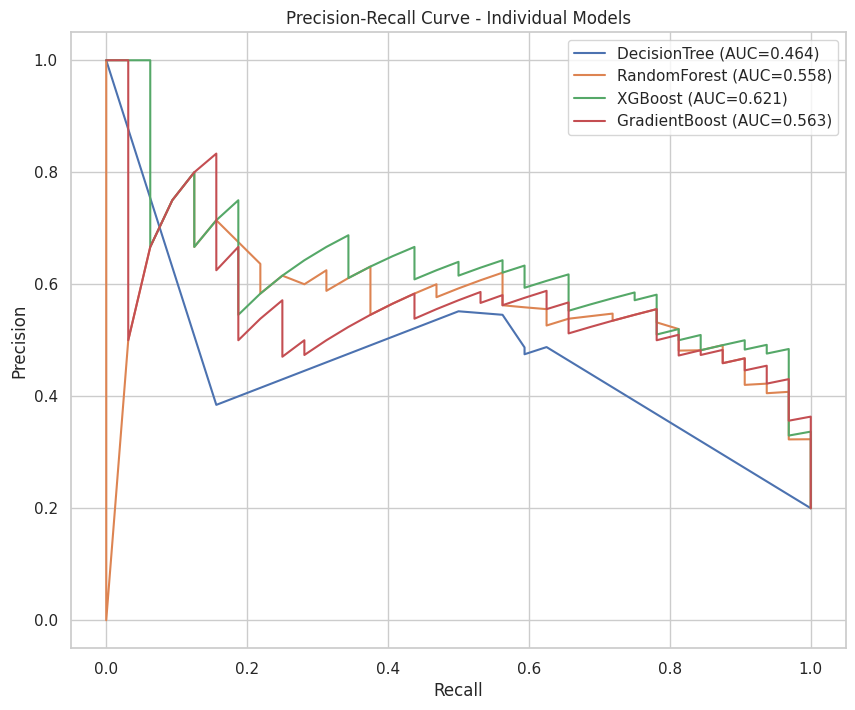

Ensemble Test Accuracy: 0.8125
Ensemble Recall: 0.8125

Classification Report (Ensemble):
              precision    recall  f1-score   support

           0       0.95      0.81      0.87       128
           1       0.52      0.81      0.63        32

    accuracy                           0.81       160
   macro avg       0.73      0.81      0.75       160
weighted avg       0.86      0.81      0.83       160



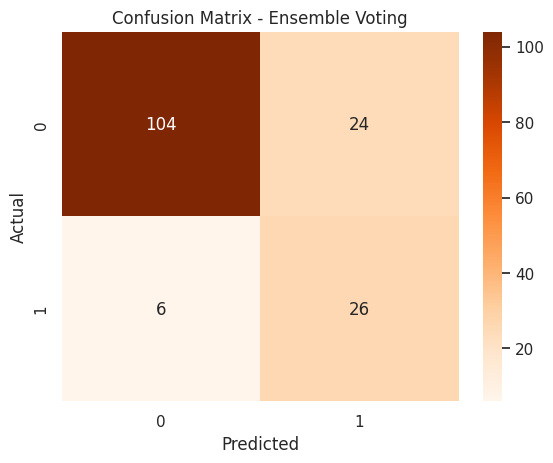

In [ ]:
from sklearn.ensemble import VotingClassifier
from sklearn.metrics import precision_recall_curve, auc ,recall_score

# 1️⃣ Precision-Recall Curve
plt.figure(figsize=(10, 8))

for name, model in [('DecisionTree', random_search_dt.best_estimator_),
                    ('RandomForest', random_search_rf.best_estimator_),
                    ('XGBoost', random_search_xgb.best_estimator_),
                    ('GradientBoost', random_search_gb.best_estimator_)]:

    # predicted probabilities
    y_probs = model.predict_proba(x_test_scaled)[:, 1]

    precisions, recalls, _ = precision_recall_curve(y_test, y_probs)
    pr_auc = auc(recalls, precisions)

    plt.plot(recalls, precisions, label=f'{name} (AUC={pr_auc:.3f})')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve - Individual Models')
plt.legend()
plt.grid(True)
plt.show()

# 2️⃣ Ensemble Voting Classifier
ensemble_model = VotingClassifier(
    estimators=[
        ('rf', random_search_rf.best_estimator_),
        ('xgb', random_search_xgb.best_estimator_),
        ('gb', random_search_gb.best_estimator_)
    ],
    voting='soft',  # use predicted probabilities
    n_jobs=-1
)

ensemble_model.fit(x_train_smote, y_train_smote)

# Threshold tuning for ensemble
y_probs_ensemble = ensemble_model.predict_proba(x_test_scaled)[:, 1]
precisions, recalls, thresholds = precision_recall_curve(y_test, y_probs_ensemble)

desired_recall = 0.80
idx = np.where(recalls >= desired_recall)[0]
optimal_threshold_ensemble = thresholds[idx[-1]] if len(idx) > 0 else 0.5

y_pred_ensemble = (y_probs_ensemble >= optimal_threshold_ensemble).astype(int)

print('='*50)
print(f'Ensemble Test Accuracy: {accuracy_score(y_test, y_pred_ensemble):.4f}')
print(f'Ensemble Recall: {recall_score(y_test, y_pred_ensemble):.4f}')
print('='*50)
print('\nClassification Report (Ensemble):')
print(classification_report(y_test, y_pred_ensemble))

# Confusion matrix
cm_ensemble = confusion_matrix(y_test, y_pred_ensemble)
sns.heatmap(cm_ensemble, annot=True, fmt='d', cmap='Oranges')
plt.title(f'Confusion Matrix - Ensemble Voting')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

#


✅ Baseline: Best Model (Threshold=0.5)
Accuracy: 0.8250
Recall  : 0.6562
Precision: 0.5526
F1-score : 0.6000
              precision    recall  f1-score   support

           0       0.91      0.87      0.89       128
           1       0.55      0.66      0.60        32

    accuracy                           0.82       160
   macro avg       0.73      0.76      0.74       160
weighted avg       0.84      0.82      0.83       160



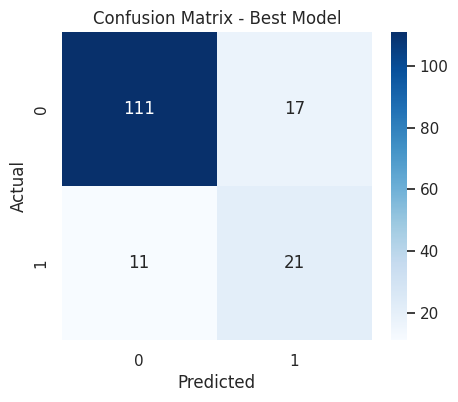

In [ ]:
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================
# Baseline: Best Model (Threshold = 0.5)
# ==========================
y_pred_best = best_model.predict(x_test_scaled)

accuracy_best = accuracy_score(y_test, y_pred_best)
recall_best   = recall_score(y_test, y_pred_best)
precision_best= precision_score(y_test, y_pred_best)
f1_best       = f1_score(y_test, y_pred_best)

print("="*50)
print("✅ Baseline: Best Model (Threshold=0.5)")
print(f"Accuracy: {accuracy_best:.4f}")
print(f"Recall  : {recall_best:.4f}")
print(f"Precision: {precision_best:.4f}")
print(f"F1-score : {f1_best:.4f}")
print("="*50)
print(classification_report(y_test, y_pred_best))

# Confusion Matrix
cm_best = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(5,4))
sns.heatmap(cm_best, annot=True, fmt='d', cmap='Blues')
plt.title(f'Confusion Matrix - Best Model')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# 9. Neural Network

In [ ]:
model = Sequential()
model.add(Dense(64, activation='relu', input_shape=(x_train.shape[1],)))
model.add(Dropout(0.4))
model.add(Dense(32, activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(16, activation='relu'))
model.add(Dense(1, activation='sigmoid'))
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         1,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,905 (15.25 KB)

 Trainable params: 3,905 (15.25 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)


# ✅ Bug Fix: التدريب على x_train_smote مش x_train
history = model.fit(
    x_train_smote,
    y_train_smote,
    epochs=50,
    batch_size=32,
    validation_data=(x_test_scaled, y_test),
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.5626 - loss: 0.6401 - val_accuracy: 0.8062 - val_loss: 0.4786
Epoch 2/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7456 - loss: 0.5000 - val_accuracy: 0.7937 - val_loss: 0.3786
Epoch 3/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8425 - loss: 0.4062 - val_accuracy: 0.7812 - val_loss: 0.3779
Epoch 4/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8728 - loss: 0.3451 - val_accuracy: 0.7688 - val_loss: 0.4100
Epoch 5/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8659 - loss: 0.3240 - val_accuracy: 0.7688 - val_loss: 0.4132
Epoch 6/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8796 - loss: 0.3212 - val_accuracy: 0.7812 - val_loss: 0.4037


Neural Network Test Accuracy: 0.7812
Neural Network Test Loss: 0.3779
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.76      0.85       128
           1       0.47      0.88      0.62        32

    accuracy                           0.78       160
   macro avg       0.72      0.82      0.73       160
weighted avg       0.86      0.78      0.80       160



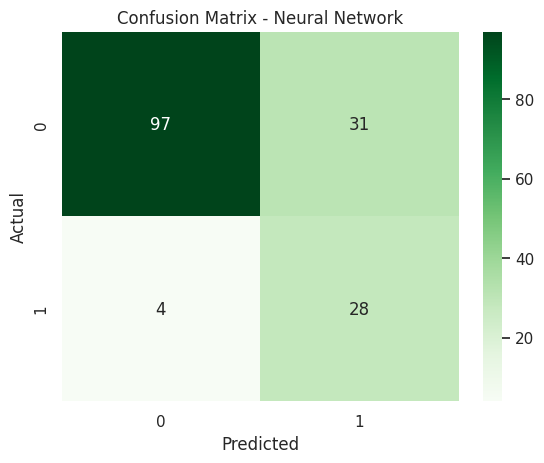

In [ ]:
loss, acc = model.evaluate(x_test_scaled, y_test, verbose=0)
print(f'Neural Network Test Accuracy: {acc:.4f}')
print(f'Neural Network Test Loss: {loss:.4f}')

y_pred_nn = (model.predict(x_test_scaled) > 0.5).astype(int)
print('\nClassification Report:')
print(classification_report(y_test, y_pred_nn))

cm_nn = confusion_matrix(y_test, y_pred_nn)
sns.heatmap(cm_nn, annot=True, fmt='d', cmap='Greens')
plt.title('Confusion Matrix - Neural Network')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

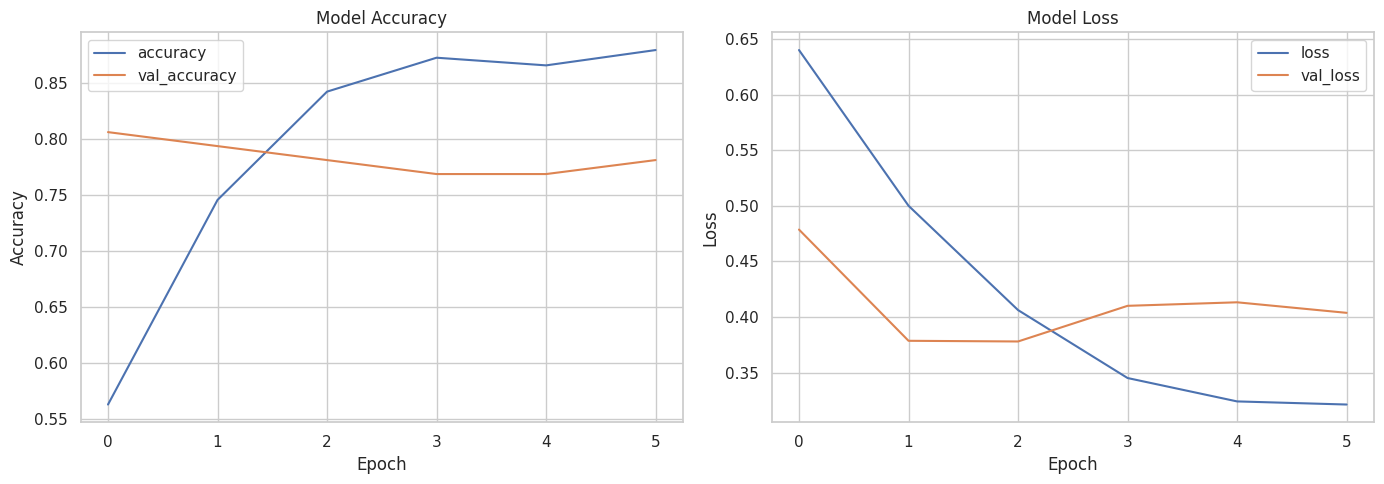

In [ ]:
# Training History
results = pd.DataFrame(history.history)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

results[['accuracy', 'val_accuracy']].plot(ax=axes[0])
axes[0].set_title('Model Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')

results[['loss', 'val_loss']].plot(ax=axes[1])
axes[1].set_title('Model Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')

plt.tight_layout()
plt.show()

# 8. Recall Optimization: Threshold Tuning
To further improve recall, we can adjust the classification threshold. By default, the threshold is 0.5. Lowering it will increase recall.

Optimal Threshold for 80.0% Recall: 0.2914
New Test Accuracy: 0.8125
New Recall: 0.8125

New Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.81      0.87       128
           1       0.52      0.81      0.63        32

    accuracy                           0.81       160
   macro avg       0.73      0.81      0.75       160
weighted avg       0.86      0.81      0.83       160



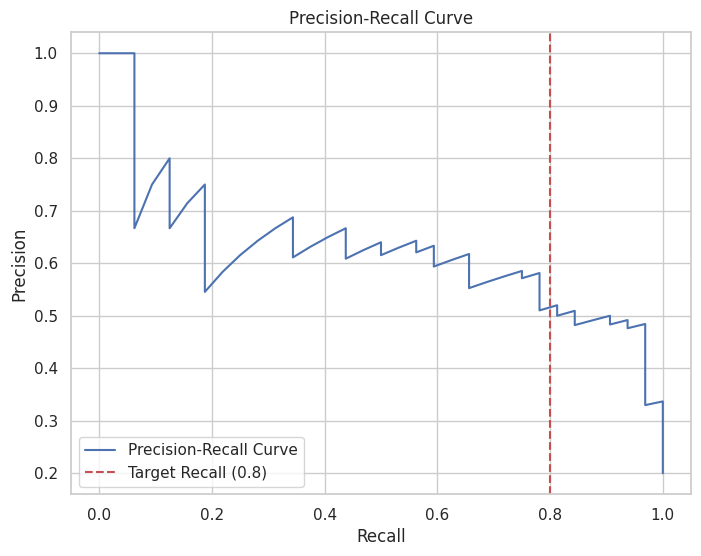

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, recall_score
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt
import numpy as np

# Get predicted probabilities for the positive class
y_probs = best_model.predict_proba(x_test_scaled)[:, 1]

# Calculate precision and recall for different thresholds
precisions, recalls, thresholds = precision_recall_curve(y_test, y_probs)

# Find a threshold that gives us a higher recall (e.g., > 0.80)
desired_recall = 0.80
idx = np.where(recalls >= desired_recall)[0]
if len(idx) > 0:
    optimal_threshold = thresholds[idx[-1]]
else:
    optimal_threshold = 0.5

print(f'Optimal Threshold for {desired_recall*100}% Recall: {optimal_threshold:.4f}')

# Apply the new threshold
y_pred_new = (y_probs >= optimal_threshold).astype(int)

print('=' * 50)
print(f'New Test Accuracy: {accuracy_score(y_test, y_pred_new):.4f}')
print(f'New Recall: {recall_score(y_test, y_pred_new):.4f}')
print('=' * 50)
print('\nNew Classification Report:')
print(classification_report(y_test, y_pred_new))

# Plot Precision-Recall Curve
plt.figure(figsize=(8, 6))
plt.plot(recalls, precisions, label='Precision-Recall Curve')
plt.axvline(x=desired_recall, color='r', linestyle='--', label=f'Target Recall ({desired_recall})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.show()